In [ ]:
from IPython.display import HTML

html_content = '''
<div style="font-family: 'Segoe UI', Arial, sans-serif; max-width: 900px; margin: 0 auto; line-height: 1.6; color: #e0e0e0; background-color: #0d1117; padding: 20px; border-radius: 8px;">
    <h1 style="color: #58a6ff; border-bottom: 3px solid #3498db; padding-bottom: 10px;">Transport Data Preparation for OECD Analysis Dashboard</h1>
    
    <div style="background-color: #161b22; padding: 20px; border-left: 5px solid #3498db; margin: 20px 0;">
        <h2 style="color: #58a6ff; margin-top: 0;">Overview</h2>
        <p style="text-align: justify;">
            This notebook focuses on preparing OECD Transport Performance Indicators data for visualization in a Streamlit dashboard. 
            The primary purpose is to transform raw transportation metrics from various countries into clean, analysis-ready datasets 
            that can be easily loaded into interactive visualizations.
        </p>
    </div>

    <div style="background-color: #161b22; padding: 20px; border-left: 5px solid #2ecc71; margin: 20px 0;">
        <h2 style="color: #58a6ff; margin-top: 0;">Data Source</h2>
        <p>
            The primary data is from the <a href="https://data-explorer.oecd.org/vis?lc=en&fs[0]=Topic%2C0%7CTransport%23TRA%23&pg=0&fc=Topic&snb=22&df[ds]=dsDisseminateFinalDMZ&df[id]=DSD_INDICATORS%40DF_TRANSPORTINDICATORS&df[ag]=OECD.ITF&df[vs]=1.0&dq=.A.FREIGHT..ROAD...&lom=LASTNPERIODS&lo=5&to[TIME_PERIOD]=false" style="color: #58a6ff; text-decoration: none; border-bottom: 1px dotted #58a6ff;">OECD Data Explorer, Transport Performance Indicators</a>, supplemented with economic indicators for contextual analysis.
        </p>
        
        <div style="background-color: #0d1117; padding: 15px; border-radius: 5px; margin-top: 15px;">
            <p style="margin: 0;">The dataset includes more than 90 performance indicators related to transport across 70 countries.</p>
            <p style="margin: 10px 0 0 0;">The indicators cover seven themes:</p>
            <div style="display: flex; flex-wrap: wrap; gap: 10px; margin-top: 10px;">
                <span style="background-color: #3498db; color: white; padding: 5px 10px; border-radius: 3px;">infrastructure</span>
                <span style="background-color: #2ecc71; color: white; padding: 5px 10px; border-radius: 3px;">equipment</span>
                <span style="background-color: #e74c3c; color: white; padding: 5px 10px; border-radius: 3px;">activity</span>
                <span style="background-color: #f39c12; color: white; padding: 5px 10px; border-radius: 3px;">safety</span>
                <span style="background-color: #9b59b6; color: white; padding: 5px 10px; border-radius: 3px;">traffic</span>
                <span style="background-color: #1abc9c; color: white; padding: 5px 10px; border-radius: 3px;">economic and social</span>
                <span style="background-color: #34495e; color: white; padding: 5px 10px; border-radius: 3px;">environment</span>
            </div>
        </div>
    </div>

    <div style="background-color: #161b22; padding: 20px; border-left: 5px solid #e74c3c; margin: 20px 0;">
        <h2 style="color: #58a6ff; margin-top: 0;">Data Processing Pipeline</h2>
        
        <div style="margin: 20px auto; max-width: 900px;">
            <table style="width:100%; border-collapse: separate; border-spacing: 5px; color: white;">
                <!-- Input Sources -->
                <tr>
                    <td style="width:45%; text-align:center; background-color:#3498db; padding:10px; border-radius:5px; color:white; font-weight:bold;">Raw OECD Transport Data</td>
                    <td style="width:10%;"></td>
                    <td style="width:45%; text-align:center; background-color:#3498db; padding:10px; border-radius:5px; color:white; font-weight:bold;">Raw OECD Economic Data</td>
                </tr>
                
                <!-- Processing Arrows -->
                <tr>
                    <td style="text-align:center; color: #e0e0e0;">↓</td>
                    <td></td>
                    <td style="text-align:center; color: #e0e0e0;">↓</td>
                </tr>
                
                <!-- First Processing Step -->
                <tr>
                    <td style="text-align:center; background-color:#2ecc71; padding:10px; border-radius:5px; color: black; font-weight:bold;">Data Cleaning & Standardization</td>
                    <td></td>
                    <td style="text-align:center; background-color:#2ecc71; padding:10px; border-radius:5px; color: black; font-weight:bold;">Economic Data Cleaning</td>
                </tr>
                
                <!-- Processing Arrows -->
                <tr>
                    <td style="text-align:center; color: #e0e0e0;">↓</td>
                    <td></td>
                    <td style="text-align:center; color: #e0e0e0;">↓</td>
                </tr>
                
                <!-- Second Processing Step -->
                <tr>
                    <td style="text-align:center; background-color:#f39c12; padding:10px; border-radius:5px; color: black; font-weight:bold;">Country & Metric Filtering</td>
                    <td></td>
                    <td style="text-align:center; background-color:#f39c12; padding:10px; border-radius:5px; color: black; font-weight:bold;">Filter to Match Transport Countries</td>
                </tr>
                
                <!-- Processing Arrows -->
                <tr>
                    <td style="text-align:center; color: #e0e0e0;">↓</td>
                    <td></td>
                    <td style="text-align:center; color: #e0e0e0;">↓</td>
                </tr>
                
                <!-- Third Processing Step - Branching -->
                <tr>
                    <td style="text-align:center; background-color:#e74c3c; padding:10px; border-radius:5px; color: black; font-weight:bold;">Time Series Regression & Format Transformation</td>
                    <td></td>
                    <td style="text-align:center; background-color:#e74c3c; padding:10px; border-radius:5px; color: black; font-weight:bold;">Time Series Regression & Format Transformation</td>
                </tr>
                
                <!-- Processing Arrows with Branching -->
                <tr>
                    <td style="text-align:center; color: #e0e0e0;">↙︎ &nbsp; &nbsp; &nbsp; ↘︎</td>
                    <td></td>
                    <td style="text-align:center; color: #e0e0e0;">↙︎ &nbsp; &nbsp; &nbsp; ↘︎</td>
                </tr>
                
                <!-- Fourth Processing Step - Output Files (2 per dataset) -->
                <tr>
                    <td style="width:45%;">
                        <div style="text-align:center; background-color:#9b59b6; padding:8px; border-radius:5px; margin-bottom:10px; color:white; font-weight:bold;">
                            transport_metrics_agg_wide.csv<br>
                            <small>(Aggregated format)</small>
                        </div>
                        <div style="text-align:center; background-color:#9b59b6; padding:8px; border-radius:5px; color:white; font-weight:bold;">
                            transport_metrics_semiwide.csv<br>
                            <small>(Time series format)</small>
                        </div>
                    </td>
                    <td></td>
                    <td style="width:45%;">
                        <div style="text-align:center; background-color:#9b59b6; padding:8px; border-radius:5px; margin-bottom:10px; color:white; font-weight:bold;">
                            econ_metrics_agg_wide.csv<br>
                            <small>(Aggregated format)</small>
                        </div>
                        <div style="text-align:center; background-color:#9b59b6; padding:8px; border-radius:5px; color:white; font-weight:bold;">
                            econ_metrics_semiwide.csv<br>
                            <small>(Time series format)</small>
                        </div>
                    </td>
                </tr>
                
                <!-- Processing Arrows Converging -->
                <tr>
                    <td style="text-align:center; color: #e0e0e0;">↘︎</td>
                    <td style="text-align:center; color: #e0e0e0;">↓</td>
                    <td style="text-align:center; color: #e0e0e0;">↙︎</td>
                </tr>
                
                <!-- Metadata Generation -->
                <tr>
                    <td colspan="3" style="text-align:center; background-color:#34495e; padding:10px; border-radius:5px; color:white; font-weight:bold;">
                        Metadata Generation
                    </td>
                </tr>
                
                <!-- Final Output Files -->
                <tr>
                    <td style="text-align:center; color: #e0e0e0;">↓</td>
                    <td style="text-align:center; color: #e0e0e0;">↓</td>
                    <td style="text-align:center; color: #e0e0e0;">↓</td>
                </tr>
                
                <tr>
                    <td style="text-align:center; background-color:#1abc9c; padding:8px; border-radius:5px; color: black; font-weight:bold;">
                        combined_measure_metadata.csv<br>
                        <small>(Measure metadata after time-series aggregation)</small>
                    </td>
                    <td style="text-align:center; background-color:#1abc9c; padding:8px; border-radius:5px; color: black; font-weight:bold;">
                        measure_yearly_metadata.csv<br>
                        <small>(Measure metadata without time-series aggregation)</small>
                    </td>
                    <td></td>
                </tr>
            </table>
        </div>
    </div>

    <div style="background-color: #161b22; padding: 20px; border-left: 5px solid #f39c12; margin: 20px 0;">
        <h2 style="color: #58a6ff; margin-top: 0;">Key Transformation Steps</h2>
        
        <ol style="padding-left: 20px;">
            <li style="margin-bottom: 10px;"><strong style="color: #ff7b72;">1. Data Cleaning:</strong> Handle missing values, standardize formats, merge related columns</li>
            <li style="margin-bottom: 10px;"><strong style="color: #ff7b72;">2. Filtering:</strong> Select high-information countries (43 countries with at least 30 metrics each)</li>
            <li style="margin-bottom: 10px;"><strong style="color: #ff7b72;">3. Time Series Compression:</strong> Represent yearly data with linear regression parameters (predicted 2000 value + slope)</li>
            <li style="margin-bottom: 10px;"><strong style="color: #ff7b72;">4. Dimension Handling:</strong> Create specialized formats for all analyses (aggregated, wide, and semi-wide)</li>
            <li style="margin-bottom: 10px;"><strong style="color: #ff7b72;">5. Metadata Creation:</strong> Document measures, units, and categories for dashboard integration</li>
        </ol>
    </div>

    <div style="background-color: #161b22; padding: 20px; border-left: 5px solid #9b59b6; margin: 20px 0;">
        <h2 style="color: #58a6ff; margin-top: 0;">Output Files</h2>
        
        <div style="overflow-x: auto;">
            <table style="width: 100%; border-collapse: collapse; margin-top: 15px; color: white;">
                <thead>
                    <tr style="background-color: #34495e; color: white;">
                        <th style="padding: 10px; text-align: left; border: 1px solid #30363d;">Filename</th>
                        <th style="padding: 10px; text-align: left; border: 1px solid #30363d;">Description</th>
                        <th style="padding: 10px; text-align: left; border: 1px solid #30363d;">Dimensions</th>
                        <th style="padding: 10px; text-align: left; border: 1px solid #30363d;">Purpose</th>
                    </tr>
                </thead>
                <tbody>
                    <tr style="background-color: #0d1117;">
                        <td style="padding: 8px; border: 1px solid #30363d;"><code style="color: #58a6ff;">transport_metrics_agg_wide.csv</code></td>
                        <td style="padding: 8px; border: 1px solid #30363d;">Aggregated transport metrics in wide format</td>
                        <td style="padding: 8px; border: 1px solid #30363d;">43 rows × 78 cols</td>
                        <td style="padding: 8px; border: 1px solid #30363d;">Country clustering, correlation analysis</td>
                    </tr>
                    <tr style="background-color: #161b22;">
                        <td style="padding: 8px; border: 1px solid #30363d;"><code style="color: #58a6ff;">econ_metrics_agg_wide.csv</code></td>
                        <td style="padding: 8px; border: 1px solid #30363d;">Economic indicators in wide format</td>
                        <td style="padding: 8px; border: 1px solid #30363d;">43 rows × 18 cols</td>
                        <td style="padding: 8px; border: 1px solid #30363d;">Economic context for transport data</td>
                    </tr>
                    <tr style="background-color: #0d1117;">
                        <td style="padding: 8px; border: 1px solid #30363d;"><code style="color: #58a6ff;">transport_metrics_semiwide.csv</code></td>
                        <td style="padding: 8px; border: 1px solid #30363d;">Transport metrics with yearly values</td>
                        <td style="padding: 8px; border: 1px solid #30363d;">1289 rows × 49 cols</td>
                        <td style="padding: 8px; border: 1px solid #30363d;">Time series visualization</td>
                    </tr>
                    <tr style="background-color: #161b22;">
                        <td style="padding: 8px; border: 1px solid #30363d;"><code style="color: #58a6ff;">econ_metrics_semiwide.csv</code></td>
                        <td style="padding: 8px; border: 1px solid #30363d;">Economic indicators with yearly values</td>
                        <td style="padding: 8px; border: 1px solid #30363d;">1229 rows × 20 cols</td>
                        <td style="padding: 8px; border: 1px solid #30363d;">Economic trend visualization</td>
                    </tr>
                    <tr style="background-color: #0d1117;">
                        <td style="padding: 8px; border: 1px solid #30363d;"><code style="color: #58a6ff;">combined_measure_metadata.csv</code></td>
                        <td style="padding: 8px; border: 1px solid #30363d;">Metadata for all metrics</td>
                        <td style="padding: 8px; border: 1px solid #30363d;">59 rows × 8 cols</td>
                        <td style="padding: 8px; border: 1px solid #30363d;">Data dictionary and categorization</td>
                    </tr>
                    <tr style="background-color: #161b22;">
                        <td style="padding: 8px; border: 1px solid #30363d;"><code style="color: #58a6ff;">measure_yearly_metadata.csv</code></td>
                        <td style="padding: 8px; border: 1px solid #30363d;">Metadata for yearly metrics</td>
                        <td style="padding: 8px; border: 1px solid #30363d;">65 rows × 6 cols</td>
                        <td style="padding: 8px; border: 1px solid #30363d;">Time series documentation</td>
                    </tr>
                </tbody>
            </table>
        </div>
        
        <p style="margin-top: 15px;">These files provide the foundation for comprehensive transport infrastructure and investment analysis in the Streamlit dashboard.</p>
    </div>
</div>
'''

HTML(html_content)

In [4]:
### Block 1.1 - Data preview ###

# Exploratory Data Analysis

import pandas as pd, numpy as np
import statsmodels.api as sm


import warnings
from pandas.errors import DtypeWarning

# Importing the data and intercepting a mixed datatype warning because the relevant 
#   columns are subsequently removed.
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=DtypeWarning)
    allPerformanceIndicatorsDf = pd.read_csv('OECD_Transport_Indicators.csv')

print("Dataframe dimensions: ", allPerformanceIndicatorsDf.shape)
# (89,618, 32)

allPerformanceIndicatorsDf.head(5)


Dataframe dimensions:  (89618, 32)


,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,FREQ,Frequency of observation,MEASURE,Measure,...,OBS_VALUE,Observation value,OBS_STATUS,Observation status,OBS_STATUS2,Observation status2,UNIT_MULT,Unit multiplier,DECIMALS,Decimals
0,DATAFLOW,OECD.ITF:DSD_INDICATORS@DF_TRANSPORTINDICATORS...,Transport performance indicators,I,FIN,Finland,A,Annual,FREIGHT,Freight transport,...,1.848083,NaN,NaN,NaN,NaN,NaN,0,Units,1,One
1,DATAFLOW,OECD.ITF:DSD_INDICATORS@DF_TRANSPORTINDICATORS...,Transport performance indicators,I,FIN,Finland,A,Annual,FREIGHT,Freight transport,...,1.576170,NaN,NaN,NaN,NaN,NaN,0,Units,1,One
2,DATAFLOW,OECD.ITF:DSD_INDICATORS@DF_TRANSPORTINDICATORS...,Transport performance indicators,I,FIN,Finland,A,Annual,FREIGHT,Freight transport,...,1.792138,NaN,NaN,NaN,NaN,NaN,0,Units,1,One
3,DATAFLOW,OECD.ITF:DSD_INDICATORS@DF_TRANSPORTINDICATORS...,Transport performance indicators,I,FIN,Finland,A,Annual,FREIGHT,Freight transport,...,2.316660,NaN,NaN,NaN,NaN,NaN,0,Units,1,One
4,DATAFLOW,OECD.ITF:DSD_INDICATORS@DF_TRANSPORTINDICATORS...,Transport performance indicators,I,FIN,Finland,A,Annual,FREIGHT,Freight transport,...,2.059123,NaN,NaN,NaN,NaN,NaN,0,Units,1,One


In [5]:
### Block 1.2 - Data preview ###

allPerformanceIndicatorsDf.describe(include='all')
# The following columns are redundant in the present table (all values are repeated):
# structure_ID, Structure_name, Action, freq, Frequency of observation, Obs_status2, Decimals  

# Several columns are reundancies / transformations of others (e.g. Ref_Area & Reference Area). 
# These are left in the original table as they may be required for joins with other tables
#  from the OECD database, but I want to reduce the dimensions for immediate readability. 

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,FREQ,Frequency of observation,MEASURE,Measure,...,OBS_VALUE,Observation value,OBS_STATUS,Observation status,OBS_STATUS2,Observation status2,UNIT_MULT,Unit multiplier,DECIMALS,Decimals
count,89618,89618,89618,89618,89618,89618,89618,89618,89618,89618,...,84969.000000,0.0,6506,6506,8,8,89618.0,89618,89618.0,89618
unique,1,1,1,1,70,70,1,1,23,23,...,NaN,NaN,4,4,1,1,NaN,1,NaN,1
top,DATAFLOW,OECD.ITF:DSD_INDICATORS@DF_TRANSPORTINDICATORS...,Transport performance indicators,I,FIN,Finland,A,Annual,INVESTMENT,Investment,...,NaN,NaN,M,Missing value; data cannot exist,B,Time series break,NaN,Units,NaN,One
freq,89618,89618,89618,89618,2215,2215,89618,89618,13762,13762,...,NaN,NaN,4624,4624,8,8,NaN,89618,NaN,89618
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,129.225913,NaN,NaN,NaN,NaN,NaN,0.0,NaN,1.0,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,900.656984,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,NaN,NaN,0.0,NaN,1.0,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.755965,NaN,NaN,NaN,NaN,NaN,0.0,NaN,1.0,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.425702,NaN,NaN,NaN,NaN,NaN,0.0,NaN,1.0,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,49.604950,NaN,NaN,NaN,NaN,NaN,0.0,NaN,1.0,NaN


In [6]:
#### Block 1.3 - Data preview ###

#  Creating a subset dataframe for some early visualizations. We track country, metric, measurements, and some associated metadata.

transportIndicatorsDF = allPerformanceIndicatorsDf[
    ['Reference area', 'Measure', 'Unit of measure', 'Transport mode','TIME_PERIOD', 'OBS_VALUE']
    ]

transportIndicatorsDF.head(10)

# The top 10 shows Freight Transport in Finland, by Air, from 1994 to 2003, measured in tonne-kilometeres per 1000USD. 
# It is worth noting that this is a metric of efficiency, moreso than quantity.

# However, we also want to gain some idea of the range of values in the table, with respect to different measures, time periods, and values.
transportIndicatorsDF.sample(n=10, replace=False, random_state=32918).head(10)

# This gives us a slightly broader view of the data. Some observations on the table below:
# 1. A decent range of countries is included, so the data doesn't appear too densely concentrated in any one region.
#       However, plotting individual series of data points for 70 countries may be difficult to interpret. We will   
#       consider clustering countries of similar profiles to analyze results. 
#   <<Data Preparation TASK A>> - optional
# 2. Measure is an instance of 'long' data, with multiple categorical variables tracked within a single column.
#       We may want to pivot/reshape the dataframe later to split each metric into its own column across years.
#   <<Data Preparation TASK B>> - optional, but also a requirement for Data Preparation Task A, as clustering techniques
#       will require each row to represent a unique entity (country) and each column to represent its own metric
# 3. The Unit of Measure is a potential convolution in the data. We see that varying measure scales are present 
#       for different measures - e.g. both "per 1000 inhabitants" and "per 1 000 000 inhabitants". We should check
#       the data to make sure all values for a given measure are standardized to the same scale of unit.
#   <<Data Preparation TASK C>> - required
# 4. The main dimensions to slice values across are country, measure, transport mode, and year.
# 5. The 'Unit multiplier' column should theoretically solve the problem in obs #3, but lacks meaningful data. We can 
#       update it to our requirements as needed as part of the Data Preparation process.

,Reference area,Measure,Unit of measure,Transport mode,TIME_PERIOD,OBS_VALUE
71626,Sweden,CO2 emissions in transport sector,Percentage of CO2 emissions,Total,1997,36.129864
13448,Australia,Freight transport,Percentage of freight transport,Road,2005,46.874936
34350,Moldova,Available seat capacity for schedule flight,Per 1 000 000 US dollars,Air,2004,0.126869
49481,Georgia,Investment,Percentage of infrastructure investment,Road,2018,88.169274
23122,Denmark,Stock,Per 1 000 inhabitants,Road,1998,2.622629
32369,Sweden,Stock,Per 1 000 000 US dollars,Road,2013,0.023833
80696,Russia,Fuel deliveries to the road sector,Tonnes per person,Road,2000,0.128243
15979,Bosnia and Herzegovina,Freight transport,Tonne-kilometres per 1 000 US dollars,Rail,2008,64.982641
18797,Luxembourg,Stock,Per 1 000 000 US dollars,Road,1998,0.668102
45931,Austria,Airports,Per 1 000 000 inhabitants,Air,2015,0.694228


In [7]:
### Block 1.4 - Data preview ###

# Let's briefly familiarize ourselves with a few more dimensions of data, namely country, measure, and time period.

transportInvestment = transportIndicatorsDF[(transportIndicatorsDF['Measure'] == 'Investment')]
print("Number of records for the Measure 'Investment': ", transportInvestment.shape)
# (13,762,9)

transportInvestment.describe(include='all')
# Only 54 countries of the original 70 have investment data.

Number of records for the Measure 'Investment':  (13762, 6)


,Reference area,Measure,Unit of measure,Transport mode,TIME_PERIOD,OBS_VALUE
count,13762,13762,13762,13762,13762.000000,11491.000000
unique,54,1,3,4,NaN,NaN
top,Spain,Investment,Percentage of GDP,Road,NaN,NaN
freq,308,13762,5080,3807,NaN,NaN
mean,NaN,NaN,NaN,NaN,2008.591193,67.010384
std,NaN,NaN,NaN,NaN,7.731788,135.552096
min,NaN,NaN,NaN,NaN,1995.000000,0.000000
25%,NaN,NaN,NaN,NaN,2002.000000,0.518090
50%,NaN,NaN,NaN,NaN,2009.000000,9.193246
75%,NaN,NaN,NaN,NaN,2015.000000,75.265920


In [8]:
### Block 2.1 - Data Preparation ###

# << Data Preparation Task C - Checking 'Unit of measure' values for standardization >>

# 'Measures' and 'Unit of measure' are interrelated columns. The units used for a value
#   are a function of the domain of the 'Measure'.
 
# There are 23 measures across various traffic performance domains.
# There are 31 different 'units of measure' used across these 23 'measures'

# To check for measure consistency, find all unique tuples of ('Measure', 'Unit of measure')  
measureTuples = transportIndicatorsDF[['Measure', 'Unit of measure']].drop_duplicates()
measureTuples.sort_values(by='Measure')

,Measure,Unit of measure
38969,Airports,Per 100 square kilometres
38689,Airports,Per 1 000 000 inhabitants
17154,Available seat capacity for schedule flight,Per 1 000 inhabitants
17197,Available seat capacity for schedule flight,Per 1 000 000 US dollars
69254,CO2 emissions in transport sector,Percentage of CO2 emissions
69198,CO2 emissions in transport sector,Tonnes of CO2 per person
69170,CO2 emissions in transport sector,Percentage of CO2 emissions from transport
80838,CO2 emissions in transport sector,Kilogrammes of CO2-equivalent per 1 000 US dol...
80808,Density,Per 100 square kilometres
62688,Employment in the transport sector,Percentage of employment


In [10]:
### Block 2.2 - Data Preparation ###

# Notes on the output of the preceding Block 2.1
# Observation 1:
#   What we see is that Measure:Unit of Measure is an m:n relation
#   Some Measures have multiple Units of measurement (e.g. "Airports"), AND
#   Some Units are used for multiple measures (e.g. "Per 1 000 inhabitants")
# => Plotting values against only Measure or only Unit of Measure can result in data from
#           multiple different metrics. Any analysis should take into account both of 
#           these columns when manipulating or visualizing the data.

# Observation 2:
#   Furthermore, what we see is that while a given Measure does have several Units of 
#   measure, the difference arises not from scale but from the unit. 
#           E.g. The top 2 rows show unit variation: (Airports/area, airports/population)
#   But there are no instances of difference by scale: 
#           E.g. No case of "Stock per thousand inhabitants" AND "Stock per million inhabitants"
# => So there is no need to amend the scales of units as long as measures are considered
#           as a tuple

# The treatment of these two columns as a tuple, however, is an added complexity. We can 
#           simplify this relation by combining each measure-unit pair into a new indentifier.

transportIndicatorsDF.loc[:,'measure-unit'] = (transportIndicatorsDF['Measure'] 
                                               + ': ' 
                                               + transportIndicatorsDF['Unit of measure']
                                               )
transportIndicatorsDF.head()
# It seems natural at this stage to drop the 'Measure' and 'Unit of measure' columns but
# we retain them for filtering utility in future analyses. 

# We now have a standard Measure-Unit column for data analysis. We now proceed to tasks A and B.

,Reference area,Measure,Unit of measure,Transport mode,TIME_PERIOD,OBS_VALUE,measure-unit
0,Finland,Freight transport,Tonne-kilometres per 1 000 US dollars,Air,1994,1.848083,Freight transport: Tonne-kilometres per 1 000 ...
1,Finland,Freight transport,Tonne-kilometres per 1 000 US dollars,Air,1995,1.576170,Freight transport: Tonne-kilometres per 1 000 ...
2,Finland,Freight transport,Tonne-kilometres per 1 000 US dollars,Air,1996,1.792138,Freight transport: Tonne-kilometres per 1 000 ...
3,Finland,Freight transport,Tonne-kilometres per 1 000 US dollars,Air,1997,2.316660,Freight transport: Tonne-kilometres per 1 000 ...
4,Finland,Freight transport,Tonne-kilometres per 1 000 US dollars,Air,1998,2.059123,Freight transport: Tonne-kilometres per 1 000 ...


Countries by number of metrics available:
         Reference area  measure-unit
0   Dominican Republic             2
1             Malaysia             2
2                 Oman             3
3         Saudi Arabia             3
4              Tunisia             6
..                 ...           ...
65              Norway            39
66            Portugal            39
67              Poland            39
68           Lithuania            39
69              Latvia            39

[70 rows x 2 columns]
Plotting countries by number of metrics available: 
 Axes(0.125,0.125;0.775x0.755)


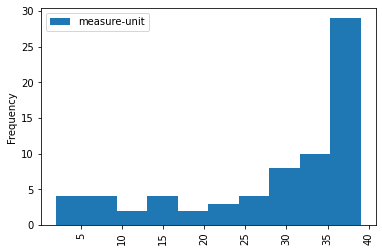

In [11]:
### Block 2.3 - Data Preparation ###

# << Data Preparation Task B - Reshaping the dataframe for Cluster analysis >>

# We want to cluster the 70 countries for which we have data into groups for analysis.
# There are 4 main sub-tasks for this:

#  B1. Check for data completeness - do all 70 countries have data on all 39 measure-unit values?
#  B2. Unpivot the measure and time columns so there is exactly one row per country, 
#      reducing 90K rows to ~70
#  B3. Trim the columns so we are only slicing across dimensions which are meaningful for 
#      our analysis. E.g. A measure like "Stock: per 1 000 000 inhabitants" may not be as 
#      interpretable for our clustering compared to "Traffic: Vehicle-kilometers per 1000 USD"
#  B4. Once we have the dataframe reshaped with one country per row, we may also want to 
#      include other meaningful economic indicators as columns, such as GDP per capita, and
#      Purchasing Power Parity, which will also provide meaningful insights into the clusters.


# B1: Checking for Data completeness.

# It is not a given that every country has released data for every metric. Let's run an aggregation
# and plot the findings. We may want to discard metrics if many countries are missing values for it.

# Country metrics aggregation - group countries and aggregate the number of unique "measure-unit" tuples for each
countryMeasuresDF = transportIndicatorsDF.groupby("Reference area").agg({"measure-unit" : pd.Series.nunique}).sort_values("measure-unit")
# This uses reference area as an index, so we reassign the column and assign a new index
print("Countries by number of metrics available:\n", countryMeasuresDF.reset_index())

# While several countries have measures for all 39 tuples, some countries such as the Dominican Republic 
# and Malaysia have just 2. We inspect the data to confirm:

transportIndicatorsDF[(transportIndicatorsDF['Reference area'] == 'Malaysia') | 
                       (transportIndicatorsDF['Reference area'] == 'Dominican Republic') 
                       ].sample(n=12, replace=False, random_state=4218).sort_values('Reference area')
# Malaysia only records passenger and freight transport, and exclusively by Rail transport
# The Dominican Republic only has records for Passenger and freight transport, and exclusively by Air.

print("Plotting countries by number of metrics available: \n", countryMeasuresDF.plot(kind = 'hist', rot = 90))




In [12]:
### Block 2.4 - Data Preparation ###

# << Data Preparation Task B - Reshaping the dataframe for Cluster analysis >>
 
# For the purpose of clustering, we should make sure that all countries are comparable across as
# many features as possible. We drop countries which have less than 30 of the 39 measure units.

# Filter countries with at least 30 metrics with a boolean mask
highInfoCountries = countryMeasuresDF[(countryMeasuresDF['measure-unit'] >= 30)].reset_index()

# Using the series above to create a new dataframe with the remaining columns
highInfoCountriesDF = transportIndicatorsDF[
        transportIndicatorsDF['Reference area'].isin(highInfoCountries['Reference area'])
        ]

print("After dropping low-info countries, we are left with a table of dimensions: ", 
      highInfoCountriesDF.shape)
# We still have over 73,000 of the original 89,617 values. 

print("The number of countries included is: ", highInfoCountriesDF['Reference area'].nunique())
# We have reduced to 43 of the original 70 countries.

highInfoCountriesDF.sample(n=10, random_state=4218)

# We now proceed to calculate our metric aggregations and append them as columns here.

After dropping low-info countries, we are left with a table of dimensions:  (73321, 7)
The number of countries included is:  43


,Reference area,Measure,Unit of measure,Transport mode,TIME_PERIOD,OBS_VALUE,measure-unit
20118,Finland,First registrations,Per 1 000 000 US dollars,Road,2003,0.002761,First registrations: Per 1 000 000 US dollars
67800,Germany,Value added by the transport sector,Percentage of value added,Total,2004,4.467049,Value added by the transport sector: Percentag...
28599,Finland,First registrations,Per 1 000 inhabitants,Road,1997,0.090664,First registrations: Per 1 000 inhabitants
68438,Estonia,Household expenditure for transport,Percentage of household expenditure,Total,2018,11.748241,Household expenditure for transport: Percentag...
36152,Belgium,First registrations,Per 1 000 inhabitants,Road,2018,0.580115,First registrations: Per 1 000 inhabitants
36470,Estonia,First registrations,Per 1 000 inhabitants,Road,2021,0.401974,First registrations: Per 1 000 inhabitants
34263,Luxembourg,Stock,Per 1 000 inhabitants,Road,2004,41.046071,Stock: Per 1 000 inhabitants
36965,Germany,First registrations,Per 1 000 000 US dollars,Road,2002,0.011427,First registrations: Per 1 000 000 US dollars
55540,Türkiye,Investment,US dollars per person,Inland,2005,37.948985,Investment: US dollars per person
8642,Mexico,Freight transport,Percentage of freight transport,Road,2021,73.033691,Freight transport: Percentage of freight trans...


In [13]:
### Block 2.5 - Data Preparation ###

# In this block, I fix an oversight in my first approach where I was thinking of
# aggregating data across time but neglected the Transport mode column.
# 'Transport mode' captures, for relevant metric, whether the metric was measured for
# air, water, land or rail transport. It would have been easiest to aggregate all
# but I opted to retain the data for Investment by pivoting it into the measure-unit
# column (i.e. "Investment: Thousands of $" -> "Investment (rail): Thousands of $") 
# and aggregated it for non-investment measure-units. 


# We pick out a subgroup to examine for aggregation
testDF = highInfoCountriesDF[(highInfoCountriesDF['Reference area'] == 'Finland')
                                & 
                                (highInfoCountriesDF['measure-unit'] == 'Investment: US dollars per person')
                                ]

print(testDF.sort_values("TIME_PERIOD"))

# An oversight - there are multiple observations for each year due to distinct entries for each 'Transport mode'
# I also need to unpivot this column before moving on to unpivot measure-unit and time.

# We distinguish the Investment 'measure-units' further to include Transport mode. Other measure-units remain.
investmentRowsMask = (highInfoCountriesDF['Measure'] == 'Investment')

highInfoCountriesDF.loc[investmentRowsMask, 'measure-unit'] = (
    highInfoCountriesDF.loc[investmentRowsMask, 'Measure'] 
    + ' ('
    + highInfoCountriesDF.loc[investmentRowsMask, 'Transport mode']
    + '): '
    + highInfoCountriesDF.loc[investmentRowsMask, 'Unit of measure']
)

# But we still may have other metrics which use the transport modes, so we aggregate those for now
aggHighInfoCountriesDF = highInfoCountriesDF.groupby(['Reference area', 'measure-unit', 'TIME_PERIOD']).agg(
    { "OBS_VALUE" : 'sum',
     }).reset_index()

print("Original hICDF shape: ", highInfoCountriesDF.shape)
print("Aggregate aHICDF shape: ", aggHighInfoCountriesDF.shape) # This has reduced 73321 -> 43747
# Revisiting the Finland data where we spotted the non-aggregated transport investment entries:

aggHighInfoCountriesDF.head()

testDF2 = aggHighInfoCountriesDF[(aggHighInfoCountriesDF['Reference area'] == 'Finland')
                                & # By proxy for the excluded 'Measure' column for Investment
                                (aggHighInfoCountriesDF['measure-unit'] > 'I')
                                & 
                                (aggHighInfoCountriesDF['measure-unit'] < 'J')
                                ]

testDF2.sort_values("TIME_PERIOD") # No repeats!
# Now, (reference area, measure-unit, TIME_PERIOD) should have no repeated tuples and all that remains is aggregation on TIME_PERIOD

uniquesCheck = aggHighInfoCountriesDF[['Reference area', 'measure-unit', 'TIME_PERIOD']].drop_duplicates() #should do nothing
print(aggHighInfoCountriesDF.shape[0] == uniquesCheck.shape[0], "- The aggregation consolidated Transport modes.")

      Reference area     Measure        Unit of measure Transport mode  \
44338        Finland  Investment  US dollars per person           Road   
52474        Finland  Investment  US dollars per person         Inland   
52978        Finland  Investment  US dollars per person           Rail   
56674        Finland  Investment  US dollars per person      Waterways   
52979        Finland  Investment  US dollars per person           Rail   
...              ...         ...                    ...            ...   
52500        Finland  Investment  US dollars per person         Inland   
52501        Finland  Investment  US dollars per person         Inland   
44365        Finland  Investment  US dollars per person           Road   
53005        Finland  Investment  US dollars per person           Rail   
56701        Finland  Investment  US dollars per person      Waterways   

       TIME_PERIOD   OBS_VALUE                       measure-unit  
44338         1995  173.517616  Investment:

In [ ]:
### Block 2.6 - Data Preparation ###

# << Data Preparation Task B - Reshaping the dataframe for Cluster analysis >>

#  B2. Unpivot the measure and time columns so there is exactly one row per country, 
#      reducing 90K rows to ~70

# We now have filtered our data to high-information countries and addressed transport mode redundancy.
# Next, we need to address the time dimension. For each measure-unit, we have yearly observations
# (up to 30 values between 1994-2023). Rather than keeping all years as separate columns,
# we'll summarize each country's time series with a linear model.

# For each country and measure-unit combination, we'll use Ordinary Least Squares (OLS) regression:
#   Predicted Value = m*(Year-2000) + b
# We'll record:
#   1. pred2000 - the predicted value for year 2000 (based on the regression line)
#   2. slope - the annual rate of change

# This approach handles:
# - Missing years in a time series
# - Different ranges of available data across countries
# - Creates a consistent basis for comparison

# Group by country and measure-unit
groupedHighInfoCountriesDF = aggHighInfoCountriesDF.groupby(['Reference area', 'measure-unit'])

# Define OLS regression function
def olsCoefficients(group):
    # Remove the grouping columns from the group data
    data = group.reset_index(drop=True)
    
    y = data['OBS_VALUE']
    x = data['TIME_PERIOD']
    
    # If we have only one data point, use that value with zero slope
    if len(x) == 1:
        # Get the existing value
        obsValue = y.iloc[0]
        year = x.iloc[0]
        
        # Since we have only one point, we define the slope as 0
        # The intercept is just the observed value
        slope = 0
        intercept = obsValue
        
        # Calculate the 2000 prediction (which will be the same as obs_value)
        pred2000 = intercept  # Since slope is 0, this equals the observed value
        
        return [pred2000, slope]
    
    # If we have multiple data points, fit the regression
    try:
        slope, intercept = np.polyfit(x, y, 1)
        pred2000 = slope * 2000 + intercept
        return [pred2000, slope]
    except:
        # If regression fails for any reason, return NaN
        return [np.nan, np.nan]

# Apply OLS regression to each country-measure combination
result = groupedHighInfoCountriesDF.apply(olsCoefficients, include_groups=False)

# Create a dataframe from the results
resultDf = pd.DataFrame(result.tolist(), 
                         index=result.index, 
                         columns=['pred2000', 'slope'])

# Reset index to convert the MultiIndex into regular columns
finalDf = resultDf.reset_index()

# Preview the results
finalDf.sample(n=5, random_state=32918)

,Reference area,measure-unit,pred_2000,slope
32,Australia,Investment (Road): US dollars per person,440.512328,9.053043
221,Canada,Expenditure for personal transport equipment o...,42.071665,0.166771
326,Czechia,Investment (Inland): Percentage of GDP,1.189875,-0.001425
955,Korea,Transport infrastructure: Percentage of road n...,29.081321,3.528991
1747,Switzerland,Investment (Rail): Percentage of GDP,0.552384,0.003397


In [ ]:
### Block 2.7 - Data Preparation - Reshaping to Wide Format ###

# Now we'll reshape the data to have one row per country
# Each measure-unit will become two columns: one for pred_2000 and one for slope

# Pivot the data for pred_2000 values
wideDfPred = finalDf.pivot(index='Reference area', 
                              columns='measure-unit', 
                              values='pred2000')

# Pivot the data for slope values
wideDfSlope = finalDf.pivot(index='Reference area', 
                               columns='measure-unit', 
                               values='slope')

# Rename columns to clearly indicate what they represent
wideDfPred.columns = [f"{col}_pred2000" for col in wideDfPred.columns]
wideDfSlope.columns = [f"{col}_slope" for col in wideDfSlope.columns]

# Combine both pivoted dataframes into a single wide dataframe
wideHighInfoCountriesDF = pd.concat([wideDfPred, wideDfSlope], axis=1)

# Display the first few rows of the wide dataframe
wideHighInfoCountriesDF.head()

# We now have completed the reshaping. Each row represents a country, and each column
# represents either the predicted 2000 value or the slope for a specific measure-unit.

,Airports: Per 1 000 000 inhabitants_pred2000,Airports: Per 100 square kilometres_pred2000,Available seat capacity for schedule flight: Per 1 000 000 US dollars_pred2000,Available seat capacity for schedule flight: Per 1 000 inhabitants_pred2000,CO2 emissions in transport sector: Kilogrammes of CO2-equivalent per 1 000 US dollars_pred2000,CO2 emissions in transport sector: Percentage of CO2 emissions_pred2000,CO2 emissions in transport sector: Percentage of CO2 emissions from transport_pred2000,CO2 emissions in transport sector: Tonnes of CO2 per person_pred2000,Density: Per 100 square kilometres_pred2000,Employment in the transport sector: Percentage of employment_pred2000,...,National traffic: Seat-kilometres per 1 000 US dollars_slope,Passenger transport: Passenger-kilometres per 1 000 US dollars_slope,Stock: Per 1 000 000 US dollars_slope,Stock: Per 1 000 inhabitants_slope,Traffic: Vehicle-kilometres per 1 000 US dollars_slope,Transport infrastructure: Percentage of rail network_slope,Transport infrastructure: Percentage of road network_slope,Value added by the transport sector: Percentage of value added_slope,Vehicle distance travelled: Kilometres_slope,Vehicle purchases: Percentage of household expenditure in transport_slope
Reference area,,,,,,,,,,,,,,,,,,,,,
Australia,0.562188,0.131102,0.020700,581.712793,159.764265,22.521800,99.816654,3.888496,10.154869,5.089197,...,-2.933803,-21.893184,-0.720477,7.312536,-14.102281,NaN,0.090169,-0.020815,-114.899253,-0.310692
Austria,0.748690,7.270965,0.034102,1302.995025,78.027131,29.646487,100.000000,2.409364,136.051091,5.004546,...,0.011249,-0.602625,-0.277924,7.820072,-4.841385,1.053803,3.063984,-0.009561,-113.644372,-0.428516
Azerbaijan,0.365606,3.377788,0.081177,54.538046,742.059468,11.717884,98.258503,0.396632,6.691007,NaN,...,0.046173,-90.635675,-3.766239,4.274362,13.761090,-0.229948,0.106933,NaN,NaN,NaN
Belgium,0.392914,13.028583,0.023102,836.359009,83.638611,22.302638,99.999007,2.393752,509.654162,6.302004,...,0.000485,-17.719790,-0.237153,7.253233,-7.605356,0.724627,-1.013122,-0.027998,-28.165655,-0.034117
Bulgaria,0.310637,2.314202,0.047555,114.490200,316.886838,11.804655,99.972475,0.708781,10.993129,4.962766,...,0.106785,-24.585216,-4.349176,10.932990,NaN,0.418628,1.331443,-0.094213,NaN,0.161336


In [17]:
### Block 2.8 - Feature Selection ###


# We have completed task B2 - unpivot the data. We are left with tasks B3 and B4:

#  B3. Trim the columns so we are only slicing across dimensions which are meaningful for 
#      our analysis. E.g. A measure like "Stock: per 1 000 000 inhabitants" may not be as 
#      interpretable for our clustering compared to "Traffic: Vehicle-kilometers per 1000 USD"

# First, let's check which columns have high correlation
corrHICDF = wideHighInfoCountriesDF.iloc[:,1:].corr()

# Identify highly correlated columns (|r| > 0.8) in the lower triangle of the matrix
print("Highly correlated column pairs (indices):")
n = corrHICDF.shape[0]
for i in range(1, n):
    for j in range(0, i):
        if abs(corrHICDF.iloc[i,j]) > 0.8:
            print(i, j)

# Examine the correlated columns to decide which to keep
print("\nExamining correlated columns:")
correlated_indices = [14, 15, 27, 28, 29, 69, 70]
print(wideHighInfoCountriesDF.iloc[:, correlated_indices].columns.tolist())

# Drop redundant columns
try:
    wideHighInfoCountriesDF.drop([
        # Fuel delivery metrics (keeping per person, dropping per $)
        'Fuel deliveries to the road sector: Tonnes per 1 000 000 US dollars_pred2000',
        
        # Waterway investment metrics (keeping road investment, dropping waterways)
        'Investment (Waterways): Percentage of GDP_pred2000',
        'Investment (Waterways): Percentage of infrastructure investment_pred2000',
        'Investment (Waterways): Percentage of GDP_slope'
    ], 
    axis="columns", 
    inplace=True)
    print("Redundant columns dropped")
except:
    print("Some columns were already dropped")

# Drop less relevant columns
try: 
    wideHighInfoCountriesDF.drop([
        'Airports: Per 100 square kilometres_pred2000',
        'Available seat capacity for schedule flight: Per 1 000 000 US dollars_pred2000',
        'Available seat capacity for schedule flight: Per 1 000 inhabitants_pred2000',
        'Airports: Per 100 square kilometres_slope',
        'Available seat capacity for schedule flight: Per 1 000 000 US dollars_slope',
        'Available seat capacity for schedule flight: Per 1 000 inhabitants_slope', 
        'First registrations: Per 1 000 000 US dollars_pred2000',
        'First registrations: Per 1 000 inhabitants_pred2000',
        'Stock: Per 1 000 000 US dollars_slope',
        'Stock: Per 1 000 000 US dollars_pred2000',
        'Stock: Per 1 000 inhabitants_pred2000',
        'Stock: Per 1 000 inhabitants_slope'
    ], 
    axis="columns", 
    inplace=True)
    print("Less relevant columns dropped")
except:
    print("Some columns were already dropped")


wideHighInfoCountriesDF.head()
# Scanning the data as a sanity check,
# 1. most 'pred2000' or intercept values are within an order of magnitude across countries 
# 2. 'slope' values show a reasonable split of both positive and negative trends
# 3. However, there are still clear opportunities for further trimming. Column 4 has very little variance
#       and seems to be capturing a very subtle metric. Most values are 100 or just shy of 100. It may 
#       not be contributing a lot of information even if its correlations are seemingly non-trivial.
# 4. Again, there are tools for further dimension reduction (random forest, PCA), but I commit to my 
#       current analysis until I study those tools sufficiently.

wideHighInfoCountriesDF.to_csv('transport_metrics_agg_wide.csv')

# Save the cleaned wide format dataframe
wideHighInfoCountriesDF.to_csv('transport_metrics_agg_wide.csv')

Highly correlated column pairs (indices):
1 0
19 6
20 6
20 19
29 24
30 27
31 25
33 32
34 33
36 22
49 46
50 3
54 0
54 1
59 12
64 17
65 11
76 71
77 74
78 72
79 32
79 33
80 32
80 33
80 79
83 36
84 37
85 38

Examining correlated columns:
['Fatalities: Per 100 000 inhabitants_pred2000', 'First registrations: Per 1 000 000 US dollars_pred2000', 'Investment (Rail): Percentage of GDP_pred2000', 'Investment (Rail): Percentage of infrastructure investment_pred2000', 'Investment (Rail): US dollars per person_pred2000', 'Household expenditure for transport: Percentage of household expenditure_slope', 'International traffic: Percentage of seat capacity_slope']
Redundant columns dropped
Less relevant columns dropped


In [ ]:
### Block 2.9 - Data Preparation - Measure Metadata Extraction ###

# Now that we have our transformed and filtered measure-units, we should create
# metadata to help organize and categorize them for future analysis.

# This could have been done earlier when combining the measure and unit of measure
#   into one column, but for now we use regex to split them based on the delimiters
#   previously used in combining (e.g. colon ':' after Measure) 

import re

# Function to parse measure-unit strings
def parse_measure_unit(measureUnit):
    # Extract summary type
    parts = measureUnit.split('_')
    summaryType = parts[1] if len(parts) > 1 else 'raw'
    
    # Check if transport mode exists
    transportModeMatch = re.search(r'(\w+) \(([^)]+)\)', measureUnit)
    
    if transportModeMatch:
        measure = transportModeMatch.group(1)
        transportMode = transportModeMatch.group(2)
        
        # Extract unit of measure
        colonParts = measureUnit.split(': ', 1)
        unitOfMeasure = colonParts[1].split('_')[0] if len(colonParts) > 1 else ""
    else:
        # No transport mode
        colonParts = measureUnit.split(': ', 1)
        measure = colonParts[0]
        transportMode = None
        unitOfMeasure = colonParts[1].split('_')[0] if len(colonParts) > 1 else ""
    
    # Determine domain based on measure
    if measure in ['Airports', 'Transport infrastructure']:
        domain = 'Infrastructure'
    elif measure in ['Investment', 'Maintenance']:
        domain = 'Infrastructure Investment'
    elif measure in ['CO2 emissions in transport sector', 'Fuel deliveries to the road sector']:
        domain = 'Environmental Impact'
    elif measure in ['Employment in the transport sector', 'Value added by the transport sector'] or 'expenditure' in measureUnit.lower():
        domain = 'Economic Measures'
    elif measure == 'Fatalities':
        domain = 'Safety & Social Impacts'
    elif measure in ['Freight transport', 'Passenger transport', 'Traffic', 'Vehicle distance travelled', 'National traffic', 'International traffic']:
        domain = 'Transportation Activity'
    elif measure in ['Density', 'First registrations']:
        domain = 'Transportation Infrastructure'
    else:
        domain = 'Other'
    
    return {
        'domain': domain,
        'measure': measure,
        'transport_mode': transportMode,
        'unit_of_measure': unitOfMeasure,
        'summary_type': summaryType,
        'measure-unit': measureUnit
    }

# Get all measure-units from our wide format dataframe
measureUnits = []
for col in wideHighInfoCountriesDF.columns:
    if col.endswith('_pred2000') or col.endswith('_slope'):
        baseMeasureUnit = col.rsplit('_', 1)[0]
        if baseMeasureUnit not in measureUnits:
            measureUnits.append(baseMeasureUnit)

# Create metadata entries for each measure
rows = []
for i, mu in enumerate(measureUnits):
    parsed = parse_measure_unit(mu)
    parsed['index'] = i
    rows.append(parsed)

# Create the metadata dataframe
measureMetadataDF = pd.DataFrame(rows)

# Reorder columns for readability
measureMetadataDF = measureMetadataDF[['index', 'domain', 'measure', 'transport_mode', 'unit_of_measure', 'summary_type', 'measure-unit']]

# Save the metadata for future reference
measureMetadataDF.to_csv('transport_measure_metadata.csv')

# Preview the metadata
measureMetadataDF.head()

,index,domain,measure,transport_mode,unit_of_measure,summary_type,measure-unit
0,0,Infrastructure,Airports,None,Per 1 000 000 inhabitants,raw,Airports: Per 1 000 000 inhabitants
1,1,Environmental Impact,CO2 emissions in transport sector,None,Kilogrammes of CO2-equivalent per 1 000 US dol...,raw,CO2 emissions in transport sector: Kilogrammes...
2,2,Environmental Impact,CO2 emissions in transport sector,None,Percentage of CO2 emissions,raw,CO2 emissions in transport sector: Percentage ...
3,3,Environmental Impact,CO2 emissions in transport sector,None,Percentage of CO2 emissions from transport,raw,CO2 emissions in transport sector: Percentage ...
4,4,Environmental Impact,CO2 emissions in transport sector,None,Tonnes of CO2 per person,raw,CO2 emissions in transport sector: Tonnes of C...


In [ ]:
### Block 2.10 - Data Prep - Introducing Economic Indicators Data ###

# 1. I want to include supplemental indicators about GDP, economy, purchasing power and environment. To do so, I once 
#       again fetch data from the OECD database. I will need to recreate most of the data cleaning steps from previous 
#       steps - and do so in the subsequent code block without further explanation. The original data query is below:
#       https://data-explorer.oecd.org/vis?lc=en&df[ds]=DisseminateArchiveDMZ&df[id]=DF_DP_LIVE&df[ag]=OECD&av=true&pd=1994%2C2023&dq=SGP%2BUZB%2BARE%2BUKR%2BTUN%2BSAU%2BRUS%2BROU%2BOMN%2BMKD%2BMAR%2BMNE%2BMNG%2BMDA%2BMLT%2BMYS%2BLIE%2BKAZ%2BIND%2BGEO%2BDOM%2BHRV%2BCHN%2BKHM%2BBRA%2BBIH%2BBLR%2BAZE%2BARM%2BARG%2BALB%2BBGR%2BSRB%2BITA%2BAUS%2BAUT%2BBEL%2BCAN%2BCHL%2BCOL%2BCRI%2BCZE%2BDNK%2BEST%2BFIN%2BFRA%2BDEU%2BGRC%2BHUN%2BISL%2BIRL%2BISR%2BJPN%2BKOR%2BLVA%2BLTU%2BLUX%2BMEX%2BNLD%2BNZL%2BNOR%2BPOL%2BPRT%2BSVK%2BSVN%2BESP%2BSWE%2BCHE%2BTUR%2BGBR%2BUSA.PPP%2BTRUSTGOV%2BAVWAGE%2BWAGEGAP%2BPOLLUTIONEXP%2BGDPHRWKD%2BEMP%2BGDP...A&to[TIME_PERIOD]=false&vw=tb&lb=bt
# 2. In brief, I selected indicators pertaining to GDP, Purchasing Power Parity, Exchange Rate, Labour Productivity and Environment


economicIndicatorsDf = pd.read_csv('OECD_Supplemental_Indicators.csv') # Redundant columns were removed in excel while exploring the data.
economicIndicatorsDf.sample(n=5, random_state=32918)
# The analogue of 'measure-unit' in the first dataframe here is 'indicator-measure'

# Initial exploration of the dataset
print("Economic indicators dataframe dimensions: ", economicIndicatorsDf.shape)

# Preview the data
economicIndicatorsDf.sample(n=5, random_state=32918)

# Note the structure difference compared to transport data:
# - 'Indicator' instead of 'Measure'
# - 'Subject' as a new dimension
# - 'MEASURE' as the unit

# Create a copy for our transformations
econDF = economicIndicatorsDf.copy()

# Create a combined measure-unit identifier similar to what we did for transport data
econDF['measure-unit'] = (econDF['Indicator'] + 
                         ' (' + econDF['Subject'] + '): ' +
                         econDF['MEASURE'])

# Create a subset with key columns
econSubsetDF = econDF[['Reference area', 'measure-unit', 'TIME_PERIOD', 'OBS_VALUE']]

# Rename to match transport data naming convention
econSubsetDF = econSubsetDF.rename(columns={'Reference area': 'Reference area'})

# Display the transformed data
econSubsetDF.head()

Economic indicators dataframe dimensions:  (18962, 6)


,Reference area,measure-unit,TIME_PERIOD,OBS_VALUE
0,Albania,Exchange rates (Total): National currency unit...,1994,94.623333
1,Argentina,Exchange rates (Total): National currency unit...,1994,0.999008
2,Albania,Gross domestic product (GDP) (Total): US dolla...,2002,4751.738567
3,Albania,Gross domestic product (GDP) (Total): Million ...,2002,14497.602000
4,Argentina,Purchasing power parities (PPP) (Total): Natio...,1994,0.736237


In [ ]:
### Block 2.11 - Data Preparation - Economic Indicators Transformation ###

# Apply the same transformation pipeline to economic data as we did for transport data

# Step 1: Group economic data by country and measure-unit
groupedEconDF = econSubsetDF.groupby(['Reference area', 'measure-unit'])

# Step 2: Apply OLS regression to get pred_2000 and slope
econResults = groupedEconDF.apply(olsCoefficients, include_groups=False)

# Step 3: Convert to dataframe
econResultDf = pd.DataFrame(econResults.tolist(), 
                              index=econResults.index, 
                              columns=['pred_2000', 'slope'])
finalEconDf = econResultDf.reset_index()

# Step 4: Pivot to wide format
wideEconPred = finalEconDf.pivot(index='Reference area', 
                                    columns='measure-unit', 
                                    values='pred_2000')
wideEconSlope = finalEconDf.pivot(index='Reference area', 
                                     columns='measure-unit', 
                                     values='slope')

# Step 5: Rename columns
wideEconPred.columns = [f"{col}_pred2000" for col in wideEconPred.columns]
wideEconSlope.columns = [f"{col}_slope" for col in wideEconSlope.columns]

# Step 6: Combine into a single wide dataframe
wideEconomicIndicatorsDF = pd.concat([wideEconPred, wideEconSlope], axis=1)

# Step 7: Filter to include only countries that are in transport data
transport_countries = wideHighInfoCountriesDF.index
filteredEconomicIndicatorsDF = wideEconomicIndicatorsDF[wideEconomicIndicatorsDF.index.isin(transport_countries)]

# Step 8: Drop columns with too many missing values (8 or more nulls)
nullCounts = filteredEconomicIndicatorsDF.isnull().sum()
columnsToDrop = nullCounts[nullCounts >= 8].index.tolist()
filteredEconomicIndicatorsDF_clean = filteredEconomicIndicatorsDF.drop(columns=columnsToDrop)

# Step 9: Create economic indicators metadata
econ_rows = []
for i, mu in enumerate(econSubsetDF['measure-unit'].unique()):
    # Parse parts from the measure unit string
    parts = mu.split(': ')
    if len(parts) >= 2:
        indicatorSubject = parts[0]  # "Indicator (Subject)"
        measure = parts[1]  # "MEASURE"
        
        # Extract indicator and subject
        indicator_subject_parts = indicatorSubject.split(' (')
        indicator = indicator_subject_parts[0]
        subject = indicator_subject_parts[1].rstrip(')')
        
        # Determine domain based on indicator
        if indicator in ['Exchange rates', 'Purchasing power parities (PPP)']:
            domain = 'Economic - Currency'
        elif indicator in ['GDP per capita', 'GDP per hour worked', 'Income inequality']:
            domain = 'Economic - Production'
        elif indicator in ['Employment rate', 'Unemployment rate', 'Labour force participation rate']:
            domain = 'Economic - Labour'
        elif indicator in ['Air pollution exposure', 'Water quality']:
            domain = 'Environmental'
        else:
            domain = 'Other Economic'
        
        # Create metadata entry
        econ_rows.append({
            'index': len(measureMetadataDF) + i,
            'domain': domain,
            'measure': indicator,
            'transport_mode': None,
            'unit_of_measure': measure,
            'summary_type': 'transformed',
            'measure-unit': mu,
            'data_source': 'Economic Indicators'
        })

# Create economic metadata dataframe
economicMetadataDF = pd.DataFrame(econ_rows)

# Step 10: Combine with transport metadata
measureMetadataDF['data_source'] = 'Transport Indicators'
combinedMetadataDF = pd.concat([measureMetadataDF, economicMetadataDF], ignore_index=True)

# Step 11: Save the results
filteredEconomicIndicatorsDF_clean.to_csv('econ_metrics_agg_wide.csv')
combinedMetadataDF.to_csv('combined_measure_metadata.csv')

# Step 12: Create yearly data in semi-wide format for time series analysis
# Transform economic data to have measures as columns, but keep yearly structure
econUnpivoted = econSubsetDF.pivot_table(
    index=['Reference area', 'TIME_PERIOD'],
    columns='measure-unit',
    values='OBS_VALUE'
).reset_index()
econUnpivoted.columns.name = None

# Transform transport data similarly
transportUnpivoted = aggHighInfoCountriesDF.pivot_table(
    index=['Reference area', 'TIME_PERIOD'],
    columns='measure-unit',
    values='OBS_VALUE'
).reset_index()
transportUnpivoted.columns.name = None

# Filter economic data to only include transport countries
econFilteredUnpivoted = econUnpivoted[econUnpivoted['Reference area'].isin(highInfoCountries['Reference area'])]

# Create metadata for yearly measures
measureMetadataYrDf = []

# Add transport measures metadata
for measure in transportUnpivoted.columns[2:]:
    if ': ' in measure:
        parts = measure.split(': ')
        measureName = parts[0]
        unit = parts[1]
    else:
        measureName = measure
        unit = ""
    
    # Categorize measures
    if any(term in measureName.lower() for term in ['investment', 'maintenance']):
        category = 'Transport Investment'
    elif any(term in measureName.lower() for term in ['co2', 'emissions', 'pollution', 'fuel']):
        category = 'Environmental Impact'
    elif any(term in measureName.lower() for term in ['passenger', 'traffic', 'freight', 'vehicle']):
        category = 'Transport Activity'
    elif any(term in measureName.lower() for term in ['expenditure', 'household', 'value added']):
        category = 'Economic Impact'
    elif any(term in measureName.lower() for term in ['fatalities', 'safety']):
        category = 'Transport Safety'
    elif any(term in measureName.lower() for term in ['infrastructure', 'density', 'airports']):
        category = 'Transport Infrastructure'
    else:
        category = 'Other Transport'
    
    measureMetadataYrDf.append({
        'columnName': measure,
        'measureName': measureName,
        'unit': unit,
        'category': category,
        'dataSource': 'Transport Indicators'
    })

# Add economic measures metadata
for measure in econFilteredUnpivoted.columns[2:]:
    if ': ' in measure:
        parts = measure.split(': ')
        measureName = parts[0]
        unit = parts[1]
    else:
        measureName = measure
        unit = ""
    
    # Extract context from parentheses
    if '(' in measureName and ')' in measureName:
        context = measureName.split('(')[1].split(')')[0]
        measureBase = measureName.split('(')[0].strip()
    else:
        context = ""
        measureBase = measureName
    
    # Categorize economic measures
    if any(term in measureBase.lower() for term in ['gdp', 'income', 'gini']):
        category = 'Economic Output'
    elif any(term in measureBase.lower() for term in ['exchange rate', 'purchasing power', 'ppp']):
        category = 'Currency & Purchasing Power'
    elif any(term in measureBase.lower() for term in ['employment', 'unemployment', 'labour']):
        category = 'Labor Market'
    elif any(term in measureBase.lower() for term in ['pollution', 'air', 'water', 'co2']):
        category = 'Environment'
    else:
        category = 'Other Economic'
    
    measureMetadataYrDf.append({
        'columnName': measure,
        'measureName': measureBase,
        'context': context,
        'unit': unit,
        'category': category,
        'dataSource': 'Economic Indicators'
    })

# Create yearly measures metadata dataframe
measureMetadataYrDf = pd.DataFrame(measureMetadataYrDf)

# Save yearly datasets and metadata
transportUnpivoted.to_csv('transport_metrics_semiwide.csv')
econFilteredUnpivoted.to_csv('econ_metrics_semiwide.csv')
measureMetadataYrDf.to_csv('measure_yearly_metadata.csv')

# Final summary of created datasets
print("\nFinal Datasets Created:")
print(f"1. Transport aggregated (wideHighInfoCountriesDF): {wideHighInfoCountriesDF.shape}")
print(f"2. Economic aggregated (filteredEconomicIndicatorsDF_clean): {filteredEconomicIndicatorsDF_clean.shape}")
print(f"3. Transport yearly (transportUnpivoted): {transportUnpivoted.shape}")
print(f"4. Economic yearly (econFilteredUnpivoted): {econFilteredUnpivoted.shape}")
print(f"5. Combined metadata (combinedMetadataDF): {combinedMetadataDF.shape}")
print(f"6. Yearly metadata (measureMetadataYrDf): {measureMetadataYrDf.shape}")


Final Datasets Created:
1. Transport aggregated (wideHighInfoCountriesDF): (43, 78)
2. Economic aggregated (filteredEconomicIndicatorsDF_clean): (43, 18)
3. Transport yearly (transportUnpivoted): (1289, 49)
4. Economic yearly (econFilteredUnpivoted): (1229, 20)
5. Combined metadata (combinedMetadataDF): (59, 8)
6. Yearly metadata (measureMetadataYrDf): (65, 6)
